# Finite Difference Methods for Option Pricing

This notebook develops and implements finite-difference schemes for solving the transformed Black–Scholes PDE in order to price European call options. The focus is on translating the continuous pricing problem into a stable and efficient numerical framework.

We work in log-price space and backward time, leading to a constant-coefficient PDE that is well-suited for grid-based discretization.

We consider:

- Explicit finite-difference schemes (FTCS) for forward time stepping.
- Implicit Crank–Nicolson schemes for improved stability and accuracy.
- Matrix-based formulations of the discretized system using tri-diagonal operators.

Throughout, we emphasize the stability, convergence, and implementation efficiency of such PDE solvers.

### Structure

1. **Grid construction and transformations**
   - Log-price domain truncation and discretization.
   - Time-stepping framework for backward PDE solving.

2. **FTCS scheme implementation**
   - Explicit update rule.
   - Stability considerations and parameter constraints.

3. **Crank–Nicolson scheme**
   - Semi-implicit formulation.
   - Construction of tri-diagonal matrices.
   - Linear system solution at each time step.

4. **Boundary and terminal conditions**
   - Incorporation of payoff at maturity.
   - Treatment of truncated spatial boundaries.

5. **Numerical experiments**
   - Pricing European call options across moneyness regimes.
   - Comparison between FTCS and Crank–Nicolson results.

6. **Convergence and mesh analysis**
   - Empirical verification of second-order accuracy.
   - Sensitivity to grid resolution and time step.

7. **Delta estimation**
   - Numerical differentiation in the original price variable.
   - Interpretation of the resulting sensitivity profiles.


## 1. Grid Construction and Transformations

We transform the Black–Scholes PDE into log-space:

$$
X = \log(S), \quad \tau = T - t
$$

The transformed PDE becomes:

$$
\frac{\partial V}{\partial \tau}
=
\left(r - \frac{1}{2}\sigma^2\right)\frac{\partial V}{\partial X}
+
\frac{1}{2}\sigma^2 \frac{\partial^2 V}{\partial X^2}
-
rV
$$

an initial bounded value problem (IBVP) with constant coefficients.

We define a uniform grid:

- Space: $$ X_i = X_{\min} + i \Delta X $$
- Time: $$ \tau_n = (n+1) \Delta \tau $$

We denote the numerical approximation of the option value at grid point $(X_i, \tau_n)$ by
 $$
 V_i^n = V(X_i, \tau_n)
 $$
where $i$ indexes the spatial grid and $n$ indexes the time steps.


In [1]:
#Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.linalg import lu_factor, lu_solve

In [2]:
# Parameters
r = 0.04
sigma = 0.30
T = 1.0
K = 110

# Grid parameters
N = 100          # number of interior points
M = 100          # time steps

# Domain
X_min, X_max = -5, 10

dx = (X_max - X_min) / (N + 1)
dt = T / M

# Full grid (including boundaries)
X = np.linspace(X_min, X_max, N + 2)

# Interior points only (unknowns)
X_inner = X[1:-1]

You see that $X$-space is a uniform grid whether the $S$-space is not because it's very dense near small values of $S$ and very wide spacing at large $S$. So, grid is uniform in log-space but nonlinear in actual prices. And, this is intentional because option prices change rapidly near small $S$ and log transform stabilizes the PDE.

## 2. FTCS Scheme Implementation

We define the coefficients

$$
\nu = \frac{\sigma^2}{2}, \quad
\mu = r - \frac{\sigma^2}{2}
$$

The FTCS (Forward Time Centered Space) scheme is given by

$$
V_i^{n+1}
=
V_i^n
+
\frac{\mu \Delta \tau}{2 \Delta X} \left( V_{i+1}^n - V_{i-1}^n \right)
+
\frac{\nu \Delta \tau}{\Delta X^2} \left( V_{i+1}^n - 2V_i^n + V_{i-1}^n \right)
-
r \Delta \tau V_i^n
$$

Rewriting in tri-diagonal form

$$
V_i^{n+1}
=
a_{-1} V_{i-1}^n + a_0 V_i^n + a_1 V_{i+1}^n
$$

with

$$
a_{-1} = -\frac{\mu \Delta \tau}{2 \Delta X} + \frac{\nu \Delta \tau}{\Delta X^2}
$$

$$
a_0 = 1 - \frac{2 \nu \Delta \tau}{\Delta X^2} - r \Delta \tau
$$

$$
a_1 = \frac{\mu \Delta \tau}{2 \Delta X} + \frac{\nu \Delta \tau}{\Delta X^2}
$$

This leads to the matrix formulation

$$
\mathbf{V}^{n+1} = A \mathbf{V}^n
$$

where $A$ is a tri-diagonal matrix.

In [3]:
def build_ftcs_matrix(N, dx, dt, r, sigma):
    nu = 0.5 * sigma**2
    mu = r - 0.5 * sigma**2

    a_m1 = -mu * dt / (2 * dx) + nu * dt / dx**2
    a_0  = 1 - 2 * nu * dt / dx**2 - r * dt
    a_p1 =  mu * dt / (2 * dx) + nu * dt / dx**2

    A = (
        np.diag([a_0] * N)
        + np.diag([a_p1] * (N - 1), 1)
        + np.diag([a_m1] * (N - 1), -1)
    )

    return A, a_m1, a_0, a_p1

## 3. Crank-Nicolson Scheme

The Crank–Nicolson scheme is obtained by averaging the explicit and implicit discretizations

$$
B \mathbf{V}^{n+1} = A \mathbf{V}^n
$$

($B=I$ for the FTCS scheme). We define $\alpha$ and $\beta$ in the following way

$$
\alpha = \frac{\nu \Delta \tau}{\Delta X^2}, \qquad
\beta = \frac{\mu \Delta \tau}{2 \Delta X}
$$


For matrix $A$ (explicit part)

$$
a_{-1} = \frac{1}{2} (\alpha - \beta)
$$

$$
a_0 = 1 - \alpha - \frac{r \Delta \tau}{2}
$$

$$
a_1 = \frac{1}{2} (\alpha + \beta)
$$

For matrix $B$ (implicit part)

$$
b_{-1} = -\frac{1}{2} (\alpha - \beta)
$$

$$
b_0 = 1 + \alpha + \frac{r \Delta \tau}{2}
$$

$$
b_1 = -\frac{1}{2} (\alpha + \beta)
$$

In [4]:
def build_crank_nicolson_matrices(N, dx, dt, r, sigma):
    nu = 0.5 * sigma**2
    mu = r - 0.5 * sigma**2

    alpha = nu * dt / dx**2
    beta  = mu * dt / (2 * dx)

    # Matrix A (explicit part)
    a_m1 = 0.5 * (alpha - beta)
    a_0  = 1 - alpha - 0.5 * r * dt
    a_p1 = 0.5 * (alpha + beta)

    A = (
        np.diag([a_0] * N)
        + np.diag([a_p1] * (N - 1), 1)
        + np.diag([a_m1] * (N - 1), -1)
    )

    # Matrix B (implicit part)
    b_m1 = -0.5 * (alpha - beta)
    b_0  = 1 + alpha + 0.5 * r * dt
    b_p1 = -0.5 * (alpha + beta)

    B = (
        np.diag([b_0] * N)
        + np.diag([b_p1] * (N - 1), 1)
        + np.diag([b_m1] * (N - 1), -1)
    )

    return A, B, a_m1, a_0, a_p1, b_m1, b_0, b_p1

The matrices act on interior grid points only, while boundary values are imposed separately at each time step.

## 4. Boundary and Terminal Conditions

The terminal payoff for a European call option is

$$
V(S, T) = \max(S - K, 0)
$$

Using the transformation:

$$
S = e^X
$$

we initialize:

$$
V(X, 0) = \max(e^X - K, 0)
$$
because at $\tau =0$, since $\tau = T - t$, we have $t=T$ which means we are at maturity. 
### Boundary conditions

As $S \to 0$:

$$
V \to 0
$$

As $S \to \infty$:

$$
V \sim S - K e^{-r\tau}
$$

In [5]:
def terminal_payoff(X_inner, K):
    S = np.exp(X_inner)
    return np.maximum(S - K, 0)


def boundary_conditions(S_max, K, r, tau):   #intentionally leaving S_min because it approximates the behavior at S=0, which is 0 for a call option
    left = 0.0
    right = S_max - K * np.exp(-r * tau)
    return left, right

For $i = 1$ and $i = N$, the terms $V_0^n$ and $V_{N+1}^n$ are determined by the boundary conditions. These boundary values are incorporated by adding their contributions to the first and last entries of the solution vector at each time step.

This incorporation of boundary conditions will be applied in the implementation of the FTCS and Crank–Nicolson schemes in the next section, where numerical experiments are performed to compute and analyze option prices.

# 5. Numerical Experiments

We now use the solutions from the above matrices $A$ and $B$ along with the boundary conditions.

In [6]:
# BS Parameters
r = 0.04
sigma = 0.30
T = 1.0
K = 110

# Corresponding S values
S_inner = np.exp(X_inner)
#S_min = np.exp(X_min)
S_max = np.exp(X_max)

In [7]:
# FTCS scheme
def solve_ftcs(N, M, dx, dt, r, sigma, K, X_inner, S_max):
    A, a_m1, a_0, a_p1 = build_ftcs_matrix(N, dx, dt, r, sigma)
    V = terminal_payoff(X_inner, K)

    for n in range(M):
        tau = (n + 1) * dt
        left, right = boundary_conditions(S_max, K, r, tau)

        V_new = A @ V
        V_new[0]  += a_m1 * left
        V_new[-1] += a_p1 * right
        V = V_new

    return V

# Crank-Nicolson scheme
def solve_crank_nicolson(N, M, dx, dt, r, sigma, K, X_inner, S_max):
    A, B, a_m1, a_0, a_p1, b_m1, b_0, b_p1 = build_crank_nicolson_matrices(
        N, dx, dt, r, sigma
    )
    V = terminal_payoff(X_inner, K)

    lu, piv = lu_factor(B)

    for n in range(M):
        tau = (n + 1) * dt
        left, right = boundary_conditions(S_max, K, r, tau)

        rhs = A @ V

        rhs[0]  += a_m1 * left
        rhs[-1] += a_p1 * right

        rhs[0]  -= b_m1 * left
        rhs[-1] -= b_p1 * right

        V = lu_solve((lu, piv), rhs)

    return V

# Black-Scholes formula for European call option
def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


# Interpolation function to extract price at S0 from the FD solution
def extract_price(V_inner, X_inner, S0):
    X0 = np.log(S0)
    return np.interp(X0, X_inner, V_inner)

Note: in the above code I first applied np.linalg.solve to the solution function for the CN scheme. However, this treats the problem like it's fresh each time bringing $\mathcal{O}(N^3)$ complexity per solve. So, the total cost if it were to run $M$ time is $M \cdot \mathcal{O}(N^3)$, which is not good. Hence, in order to reduce this complexity we use LU factorization that is being done once with $\mathcal{O}(N^3)$ and each solve after $\mathcal{O}(N^2)$. 

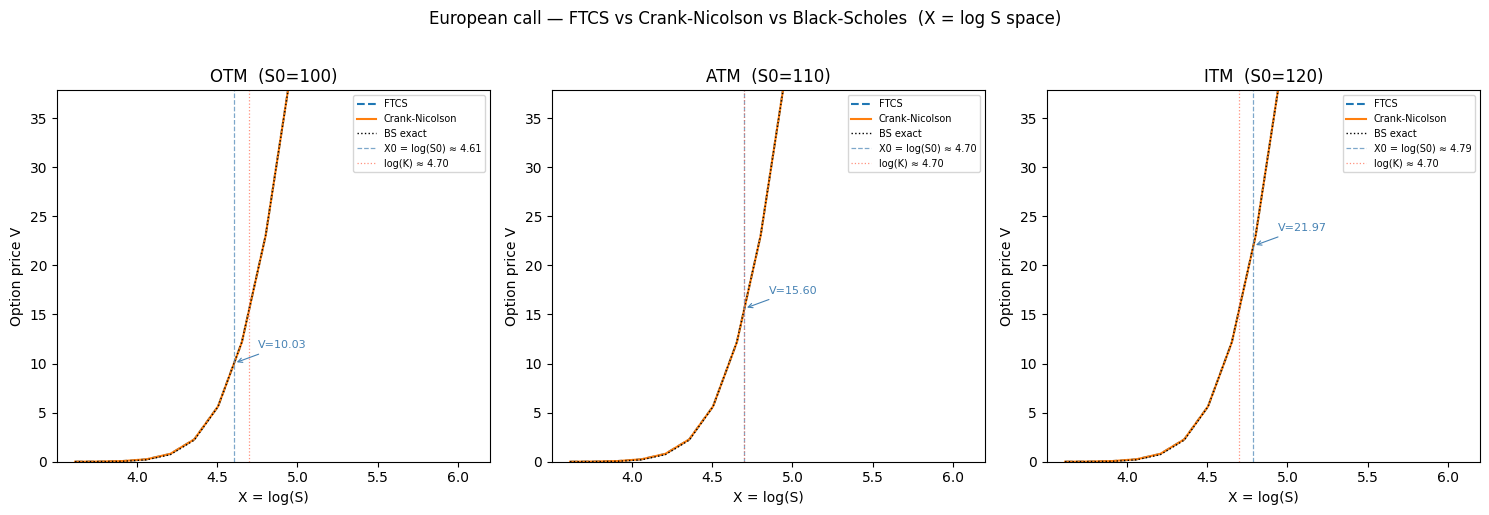

In [8]:
# three-case experiment (OTM, ATM, ITM)
cases = [
    {"label": "OTM  (S0=100)", "S0": 100},
    {"label": "ATM  (S0=110)", "S0": 110},
    {"label": "ITM  (S0=120)", "S0": 120},
]

# Plotting  
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, case in zip(axes, cases):
    S0    = case["S0"]
    label = case["label"]

    V_ftcs = solve_ftcs(N, M, dx, dt, r, sigma, K, X_inner, S_max)
    V_cn   = solve_crank_nicolson(N, M, dx, dt, r, sigma, K, X_inner, S_max)

    S_plot   = np.exp(X_inner)
    bs_curve = black_scholes_call(S_plot, K, r, sigma, T)

    X0  = np.log(S0)
    X_K = np.log(K)

    X_lo, X_hi = X_K - 1.2, X_K + 1.5       # Restrict to a narrow window around the strike for better visibility
    mask = (X_inner >= X_lo) & (X_inner <= X_hi)

    ax.plot(X_inner[mask], V_ftcs[mask], label="FTCS", lw=1.5, ls="--")
    ax.plot(X_inner[mask], V_cn[mask], label="Crank-Nicolson", lw=1.5)
    ax.plot(X_inner[mask], bs_curve[mask], label="BS exact", lw=1,  ls=":", color="k")

    ax.axvline(X0,  color="steelblue", lw=0.9, ls="--", alpha=0.7,
               label=f"X0 = log(S0) ≈ {X0:.2f}")
    ax.axvline(X_K, color="tomato",    lw=0.9, ls=":",  alpha=0.7,
               label=f"log(K) ≈ {X_K:.2f}")

    # Annotate CN price at S0
    p_cn = extract_price(V_cn, X_inner, S0)
    ax.annotate(f"V={p_cn:.2f}",
                xy=(X0, p_cn), xytext=(X0 + 0.15, p_cn + 1.5),
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=0.8),
                fontsize=8, color="steelblue")

    ax.set_title(label)
    ax.set_xlabel("X = log(S)")
    ax.set_ylabel("Option price V")
    ax.set_xlim(X_lo, X_hi)

    # Set y-axis limit based on the ATM price for better visibility
    atm_bs = black_scholes_call(K, K, r, sigma, T)
    ax.set_ylim(0, 2.5 * atm_bs)

    ax.legend(fontsize=7)

plt.suptitle("European call — FTCS vs Crank-Nicolson vs Black-Scholes  (X = log S space)",
             y=1.02)
plt.tight_layout()
plt.show()

# 6. Convergence and Mesh Analysis

We wnat to check if our schemes converge at the rate the theory predicts. That is, Crank-Nicolson scheme convergence should be 2nd order in space: halving $\Delta X$ should quarter the error. The same goes for the FTCS scheme in space (1st order in time). 


To verify this, we fix time steps M=100 and solve for either for fixed or varying N (more space points) to measure the spatial order of each scheme. We compare each FD price at S0=110 against the exact Black-Scholes price. If we plot log(error) vs log(N), a 2nd order scheme gives a straight line with slope -2.

We have that error $ \approx C \cdot {\Delta X}^p$ where $p$ the convergence rate ($p=2$ for CN). If we take the logarithm of such error, we end up with 
$$
\log(\text{error}) = \log(C) + p \cdot \log(\Delta X)
$$
which is basically a straight line. So, by plotting the logarithm of the error versus the logarithm of the $N$ values and measuring the slope, we can read off the order directly. Since, $\Delta X$ is actually the domain divided by the number $N$ (points of the grid), increasing the value of $N$ decreases $\Delta X$, so the slope flips sign and that's why we expect -2 for CN.

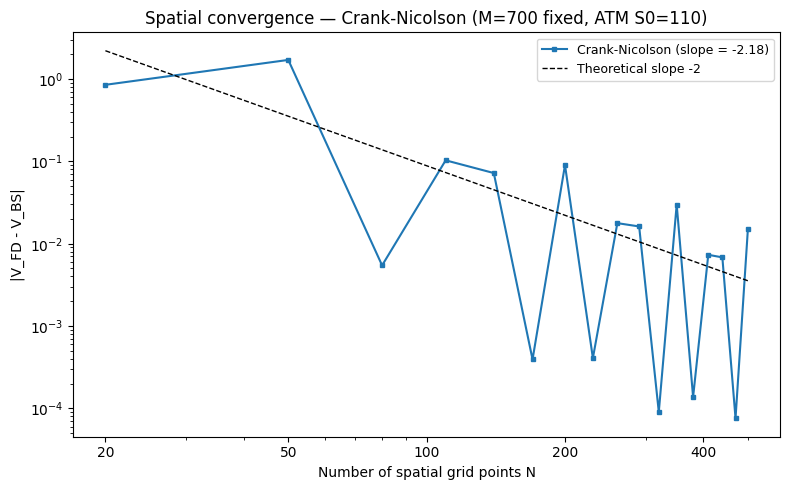

Crank-Nicolson slope: -2.183  (theory: -2)


In [72]:
S0 = 110 
M  = 700
dt = T / M
bs_price = black_scholes_call(S0, K, r, sigma, T)

N_values = np.arange(20, 501, 30)
errors_cn = []

for N_test in N_values:
    dx_test = (X_max - X_min) / (N_test + 1)
    X_in    = np.linspace(X_min, X_max, N_test + 2)[1:-1]

    idx     = np.argmin(np.abs(X_in - np.log(S0)))
    bs_here = black_scholes_call(np.exp(X_in[idx]), K, r, sigma, T)
    V_c     = solve_crank_nicolson(N_test, M, dx_test, dt, r, sigma, K, X_in, S_max)

    errors_cn.append(abs(V_c[idx] - bs_here))

N_arr     = np.array(N_values)
errors_cn = np.array(errors_cn)

slope_cn, intercept_cn = np.polyfit(np.log(N_arr), np.log(errors_cn), 1)

N_ref    = np.array([N_values[0], N_values[-1]], dtype=float)
ref_line = np.exp(intercept_cn) * N_ref ** (-2)

fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(N_arr, errors_cn, "s-", lw=1.5, ms=3,
          label=f"Crank-Nicolson (slope = {slope_cn:.2f})")
ax.loglog(N_ref, ref_line, "k--", lw=1, label="Theoretical slope -2")

ax.set_xticks([20, 50, 100, 200, 400])
ax.xaxis.set_major_formatter(plt.ScalarFormatter())

ax.set_xlabel("Number of spatial grid points N")
ax.set_ylabel("|V_FD - V_BS|")
ax.set_title(f"Spatial convergence — Crank-Nicolson (M={M} fixed, ATM S0={S0})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Crank-Nicolson slope: {slope_cn:.3f}  (theory: -2)")